In [4]:
import pandas as pd
import numpy as np
from tqdm import tqdm

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2

# Load CSVs
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

# Load a sample image
sample_id = train_df.iloc[0]["Id"]
sample_label = train_df.iloc[0]["Category"]
img_path = Path(f"train/train/{sample_label}/{sample_id}.png")

      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
Train size: 17000, Test size: 3000


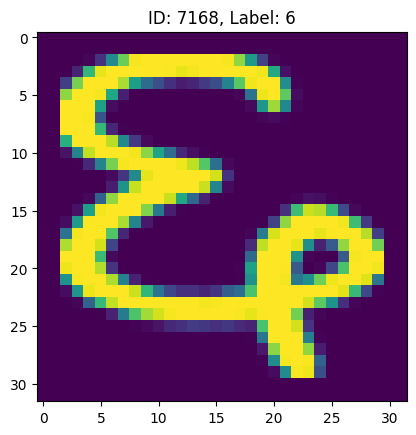

In [2]:
# view original image
img = Image.open(img_path)
plt.imshow(img)
plt.title(f"ID: {sample_id}, Label: {sample_label}")
plt.show()

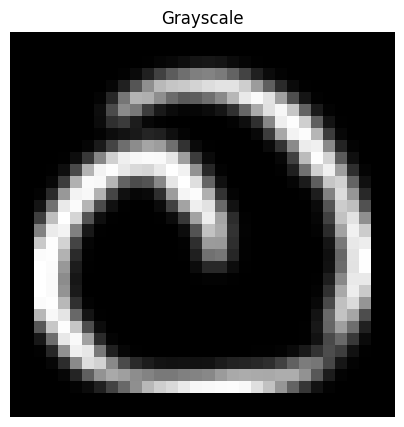

In [3]:
# convert to grayscale
# function from lab 3
def show_images(images, titles, cmap=None):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

# Pick one image from class 0
img_path = "train/train/0/103265.png"
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

show_images([gray], ["Grayscale"])

In [ ]:
# train images to grayscale
# import pandas as pd
# import numpy as np

# train_df = pd.read_csv("train.csv")

# images = []
# labels = []

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     images.append(gray)
#     labels.append(label)

# images = np.array(images)
# labels = np.array(labels)

# print(f"Loaded {len(images)} images, shape: {images.shape}")

In [ ]:
# # save grayscale images locally
# from pathlib import Path

# output_dir = Path("train_gray")
# output_dir.mkdir(exist_ok=True)

# for _, row in train_df.iterrows():
#     img_id = row["Id"]
#     label = row["Category"]
#     path = f"train/train/{label}/{img_id}.png"
    
#     img = cv2.imread(path)
#     gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#     cv2.imwrite(str(output_dir / f"{img_id}.png"), gray)

# print("Done saving grayscale images")

In [5]:
# read in grayscale images
train_df = pd.read_csv("train.csv")

images = np.array([
    cv2.imread(f"train_gray/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
    for _, row in tqdm(train_df.iterrows(), total=len(train_df))
])
labels = train_df["Category"].values

print(f"Loaded {len(images)} images, shape: {images.shape}")

100%|██████████████████████████████████████████████████████████████████████████| 17000/17000 [00:03<00:00, 4650.20it/s]

Loaded 17000 images, shape: (17000, 32, 32)


In [23]:
#a simple model to experiment with size
from tensorflow import keras
from sklearn.model_selection import train_test_split

# Flatten images: (N, 32, 32) -> (N, 1024)
X = images.reshape(len(images), -1) / 255.0  # normalize to 0-1
y = labels

# reshuffle and split into train and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=75, stratify=y)
input_size = X.shape[1]

input = keras.Input(shape=(input_size,))
h = keras.layers.Dense(128, activation="relu")(input)  
output = keras.layers.Dense(10, activation="softmax")(h)  # 10 classes, not sigmoid
model = keras.Model(input, output)

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)          │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#input_layer	Receives flattened image: 1024 pixel values
#dense_36	    Hidden layer: 1024 inputs → 128 neurons with ReLU
#dense_37	    Output layer: 128 inputs → 10 neurons (one per digit class)

In [ ]:
# check how many neurons perform best
# if a list, then this is neurons per hidden layer
configs = [
    {"hidden": 16},
    {"hidden": 64},
    {"hidden": 128},
    {"hidden": 256},
    {"hidden": [128, 64]},  # two layers
    {"hidden": [256, 128]},   # bigger two-layer
    {"hidden": [256, 256]},   # wide and deep
]

results = []

for config in configs:
    hidden = config["hidden"]
    
    # Build model
    inp = keras.Input(shape=(input_size,))
    h = inp
    if isinstance(hidden, list):
        for size in hidden:
            h = keras.layers.Dense(size, activation="relu")(h)
        label = f"[{'-'.join(map(str, hidden))}]"
    else:
        h = keras.layers.Dense(hidden, activation="relu")(h)
        label = str(hidden)
    
    out = keras.layers.Dense(10, activation="softmax")(h)
    model = keras.Model(inp, out)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    # Train
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), verbose=0)
    
    val_acc = max(history.history["val_accuracy"])
    print(f"Hidden {label}: val_accuracy = {val_acc:.4f}")
    results.append({"config": label, "val_accuracy": val_acc})

# Summary
results_df = pd.DataFrame(results).sort_values("val_accuracy", ascending=False)
print(results_df)

Hidden 16: val_accuracy = 0.9652
Hidden 64: val_accuracy = 0.9776
Hidden 128: val_accuracy = 0.9835
Hidden 256: val_accuracy = 0.9842


In [ ]:
# get best config from loop results
best_config = results_df.iloc[0]["config"]
print(f"Best config: {best_config}")

# rebuild best model
inp = keras.Input(shape=(input_size,))
h = inp
if "-" in best_config:  # two-layer config like [128-64]
    sizes = [int(s) for s in best_config.strip("[]").split("-")]
    for size in sizes:
        h = keras.layers.Dense(size, activation="relu")(h)
else:
    h = keras.layers.Dense(int(best_config), activation="relu")(h)

out = keras.layers.Dense(10, activation="softmax")(h)
best_model = keras.Model(inp, out)
best_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
best_model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val), verbose=1)
best_model.save(f"model_best_{best_config}.keras")
print(f"Saved as model_best_{best_config}.keras")

In [19]:
# load best model
best_model = keras.models.load_model(f"model_best_{best_config}.keras")

{np.int64(0): np.int64(1700), np.int64(1): np.int64(1700), np.int64(2): np.int64(1700), np.int64(3): np.int64(1700), np.int64(4): np.int64(1700), np.int64(5): np.int64(1700), np.int64(6): np.int64(1700), np.int64(7): np.int64(1700), np.int64(8): np.int64(1700), np.int64(9): np.int64(1700)}
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


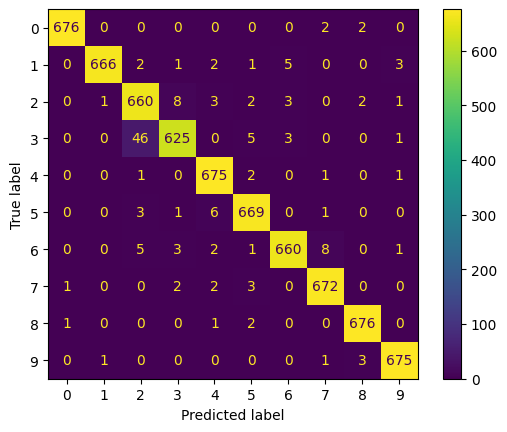

In [22]:
# 1. Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

# 2. Plot confusion matrix to see where it's making mistakes
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(best_model.predict(X_val), axis=1)

cm = confusion_matrix(y_val, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [ ]:
# write out predictions
test_df = pd.read_csv("test.csv")

test_images = np.array([
    cv2.imread(f"test/test/{row['Id']}.png", cv2.IMREAD_GRAYSCALE)
    for _, row in test_df.iterrows()
])

X_test = test_images.reshape(len(test_images), -1) / 255.0
preds = np.argmax(best_model.predict(X_test), axis=1)

submission = pd.DataFrame({"Id": test_df["Id"], "Category": preds})
submission.to_csv("submission.csv", index=False)